# Exploration de la qualité des données

Le but de ce notebook est de vérifier si les données collectées sont suffisamment fiables et pertinentes pour notre sujet.

En l'occurence, nous vérifierons dans un premier temps les valeurs manquantes, les doublons,... c'est-à-dire si les données sont colectées de manière correctes.

Ensuite, il s'agira de vérifier si ces données sont récentes, si elles concernent les joueurs et clubs qui nous intéressent et si les variables proposées sont suffisantes pour notre analyse.

Nous importons tout d'abord les packages nécessaires à notre première analyse exploratoire.

In [2]:
import sys
import os

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.append(os.path.abspath("../fonctions"))

# On importe toutes les fonctions dans le fichier imports.py
from utils import * # type: ignore

# I. Analyse de la qualité des données (Transfermarkt)

Avant d'intégrer les statistiques de performance, il est impératif de valider la fiabilité de notre variable cible : la **Valeur Marchande**. 
Cette phase permet de comprendre la structure du marché, d'identifier les segments de joueurs et de nettoyer les données pour garantir la précision du futur modèle prédictif.

### 0. Source des Données et Traçabilité
Afin de garantir la reproductibilité de cette analyse, les données sont extraites directement via l'API Kaggle. 

* **Dataset :** [Football Data from Transfermarkt](https://www.kaggle.com/datasets/davidcariboo/player-scores)
* **Identifiant (Slug) :** `davidcariboo/player-scores`
* **Dernière mise à jour du dataset :** 2026-04-01

In [ ]:
# Tu passes l'identifiant Kaggle ici
slug = 'davidcariboo/player-scores'
date_update = get_kaggle_dataset_last_update(slug)

Dataset trouvé : davidcariboo/player-scores
Dernière mise à jour : 2026-04-01 09:41:00.553000


### 1. Analyse Exploratoire de la Population
L'examen initial des distributions révèle trois piliers fondamentaux de la valorisation des joueurs :

* **Distribution des Prix :** On observe une "longue traîne" extrême. La majorité des joueurs se situe sous les 5M€, tandis qu'une élite très restreinte dépasse les 100M€. Cette asymétrie impose une approche logarithmique pour la modélisation.
* **Courbe des Âges :** La distribution suit une courbe de Gauss centrée sur **25-28 ans**. La valeur marchande étant intrinsèquement liée au potentiel de revente et au "prime" physique, l'âge sera une variable explicative non-linéaire majeure.
* **Segmentation par Ligue (Big 5) :** Les boxplots confirment un marché à plusieurs vitesses. La **Premier League** affiche non seulement la médiane la plus haute mais aussi la plus forte concentration de superstars (outliers). À talent égal, le facteur "Ligue" influence drastiquement le prix final.

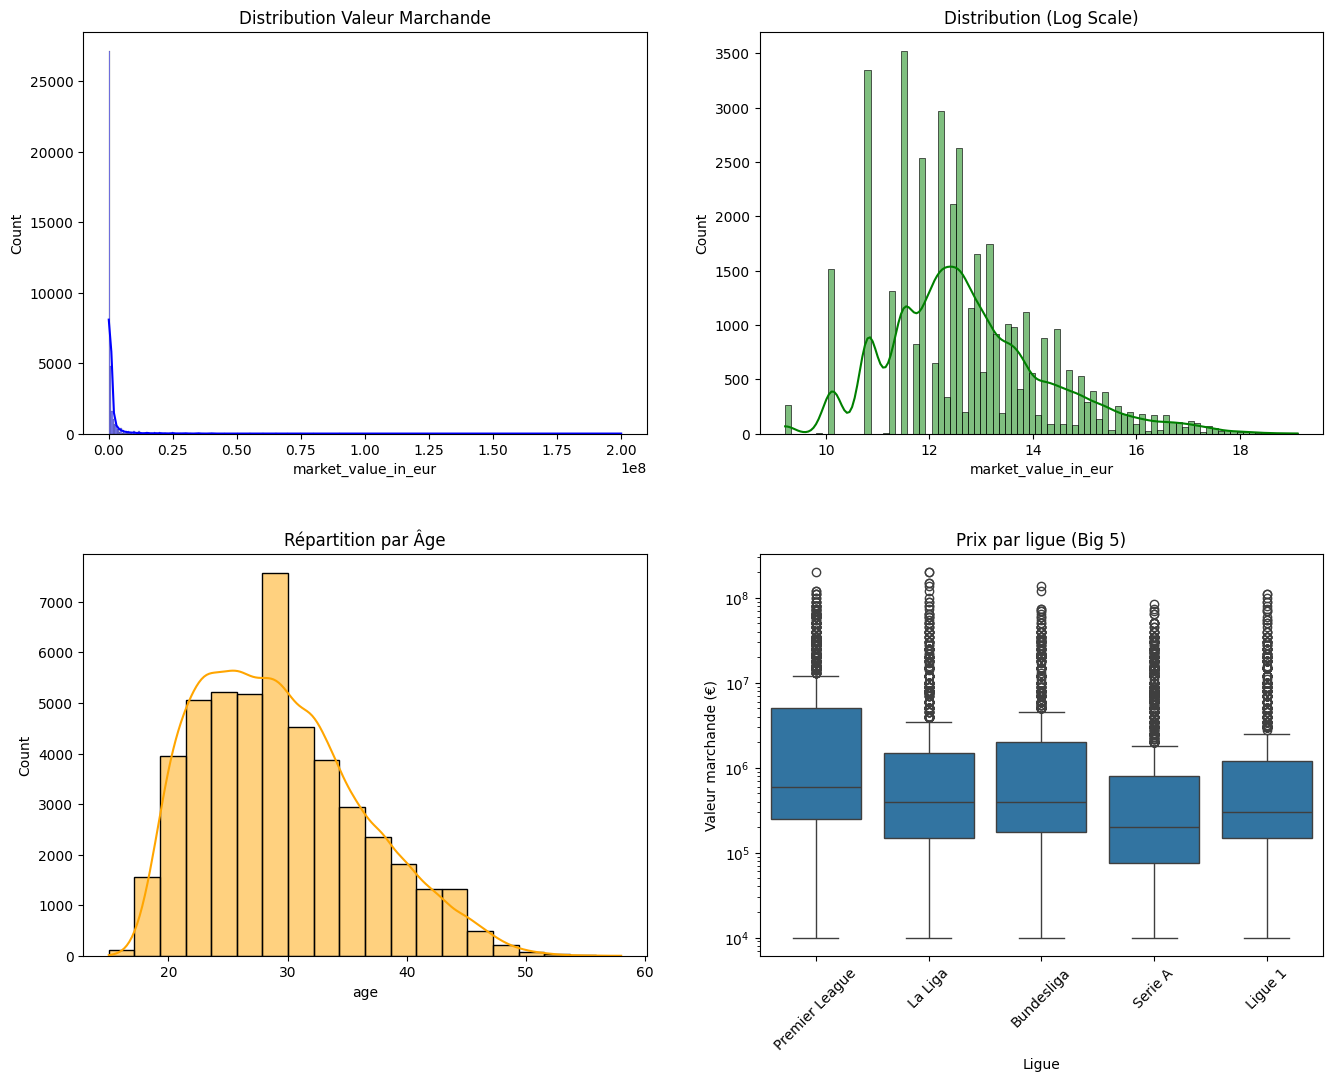

In [10]:
# Chargement des fichiers
df_players = pd.read_csv("../data/transfermarkt_datasets/players.csv")
df_clubs = pd.read_csv("../data/transfermarkt_datasets/clubs.csv")

# Appel de la fonction avec les deux DataFrames
plot_transfermarkt_quality(df_players, df_clubs)

### 2. Fraîcheur et Pertinence Temporelle
Le graphique des dates de dernières évaluations est un indicateur de fiabilité :

* **Obsolescence :** Une partie du dataset contient des prix n'ayant pas été mis à jour depuis plusieurs années (2012-2022). Ces données sont "mortes" statistiquement car elles ne correspondent plus aux performances actuelles.
* **Décision :** Pour corréler efficacement les prix aux statistiques de performance récentes, nous filtrerons les joueurs dont la dernière évaluation est antérieure à **octobre 2025**.

Nombre total d'évaluations dans l'historique : 616377
Nombre de joueurs uniques évalués : 39361
------------------------------
Date de l'évaluation la plus ancienne (historique) : 2000-01-20
Date de l'évaluation la plus récente (marché actuel) : 2026-03-30


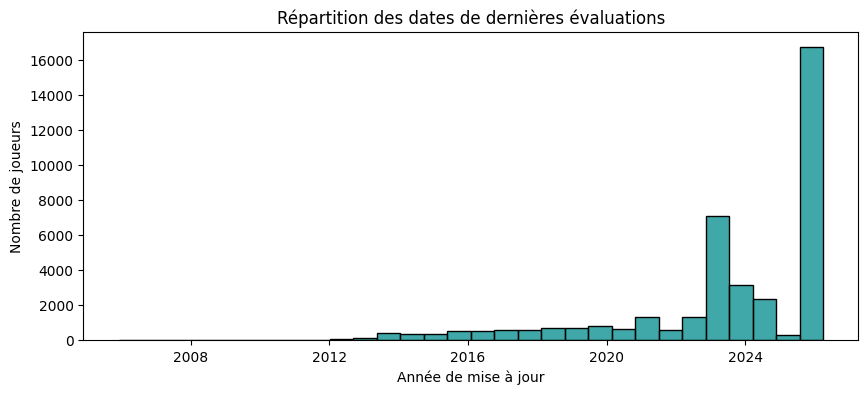

In [12]:
# 1. Chargement de l'historique des valeurs
df_valuations = pd.read_csv("../data/transfermarkt_datasets/player_valuations.csv")

# Convertir la colonne date en format datetime
df_valuations['date'] = pd.to_datetime(df_valuations['date'])

# 2. Identifier la valeur la plus récente pour chaque joueur
# On trie par date et on garde le dernier enregistrement pour chaque player_id
df_latest_values = df_valuations.sort_values('date').drop_duplicates('player_id', keep='last')

# 3. Focus sur la fraîcheur des prix (Analyse demandée)
print(f"Nombre total d'évaluations dans l'historique : {len(df_valuations)}")
print(f"Nombre de joueurs uniques évalués : {df_latest_values['player_id'].nunique()}")
print("-" * 30)
print(f"Date de l'évaluation la plus ancienne (historique) : {df_valuations['date'].min().date()}")
print(f"Date de l'évaluation la plus récente (marché actuel) : {df_valuations['date'].max().date()}")

# 4. Visualisation de la "Fraîcheur"
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.histplot(df_latest_values['date'], bins=30, color='darkcyan')
plt.title("Répartition des dates de dernières évaluations")
plt.xlabel("Année de mise à jour")
plt.ylabel("Nombre de joueurs")
plt.show()

Nombre de joueurs après filtre de fraîcheur (> 2024) : 16743
Date la plus ancienne conservée : 2025-10-01
Date la plus récente : 2026-03-30


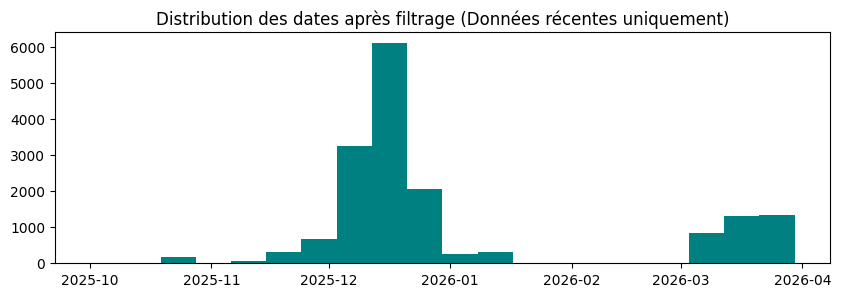

In [14]:
# --- FILTRE DE FRAÎCHEUR DES DONNÉES ---

# 1. Définir la date charnière (1er Janvier 2024)
date_seuil = pd.to_datetime('2025-10-01')

# 2. Appliquer le filtre sur df_latest_values
# On ne garde que les joueurs dont la dernière mise à jour est en 2024, 2025 ou 2026
df_latest_values = df_latest_values[df_latest_values['date'] >= date_seuil].copy()

# 3. Vérification du résultat
print(f"Nombre de joueurs après filtre de fraîcheur (> 2024) : {len(df_latest_values)}")
print(f"Date la plus ancienne conservée : {df_latest_values['date'].min().date()}")
print(f"Date la plus récente : {df_latest_values['date'].max().date()}")

# Visualisation rapide pour confirmer le nettoyage
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 3))
df_latest_values['date'].hist(bins=20, color='teal', grid=False)
plt.title("Distribution des dates après filtrage (Données récentes uniquement)")
plt.show()

### 3. Détection Statistique des Outliers (Z-Score > 3)
En utilisant la méthode du Z-score sur la valeur marchande, nous isolons mathématiquement les joueurs "hors-normes" :

* **Seuil de Rupture :** Le calcul fixe la limite de la normalité à **41.2 M€**. Au-delà, le joueur est considéré comme un outlier statistique (Top 1.7% des joueurs).
* **Visualisation Jitter :** Le graphique en échelle logarithmique montre que les outliers (en rouge) s'étendent jusqu'à 200M€. 
* **Conclusion :** Ces points ne sont pas des erreurs mais des "phénomènes". Ils nécessitent un traitement particulier pour ne pas biaiser la moyenne, tout en étant conservés pour leur haute valeur informative.

In [15]:
def detect_outliers_zscore(df, column):
    """
    Détecte les valeurs aberrantes statistiquement (Z-score > 3).
    """
    data = df[column].dropna()
    mean = np.mean(data)
    std = np.std(data)
    
    threshold = 3
    outliers = df[np.abs((df[column] - mean) / std) > threshold]
    
    print(f"Analyse de {column} :")
    print(f"- Moyenne : {mean:.2f} | Écart-type : {std:.2f}")
    print(f"- Nombre d'outliers détectés (> 3 std) : {len(outliers)}")
    
    return outliers[[column]].sort_values(by=column, ascending=False)


# --- 1. Détection sur la Valeur Marchande ---
# On utilise df_latest_values (le DataFrame avec une seule ligne par joueur)
df_latest_values = df_latest_values[df_latest_values['market_value_in_eur'] >= 1_000_000]
outliers_prix = detect_outliers_zscore(df_latest_values, 'market_value_in_eur')

Analyse de market_value_in_eur :
- Moyenne : 7255589.79 | Écart-type : 12680022.38
- Nombre d'outliers détectés (> 3 std) : 125


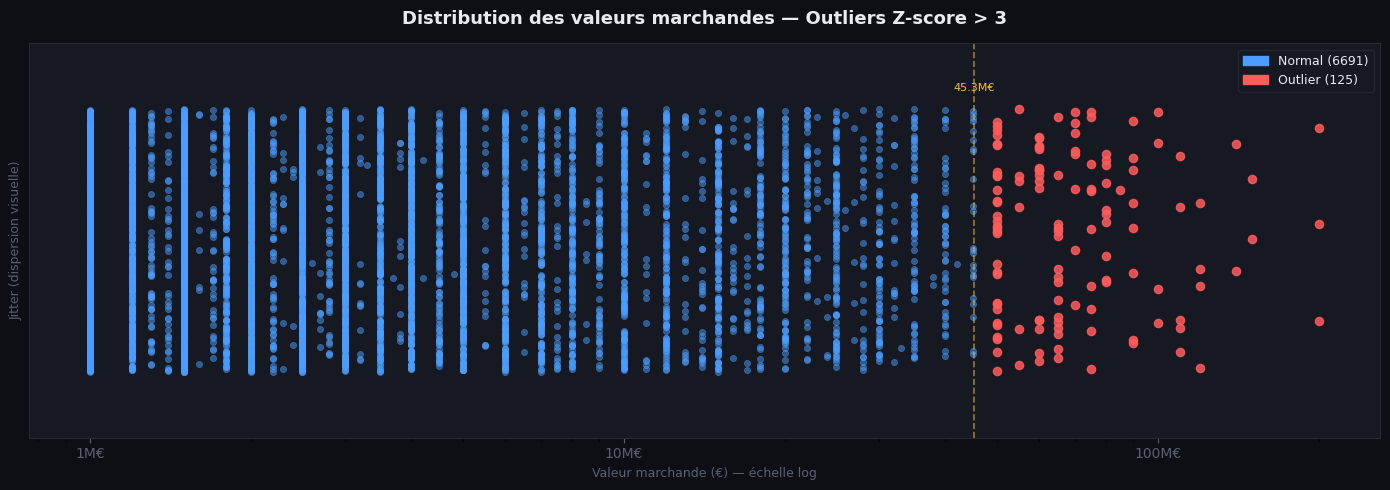

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_outliers_jitter(df, column, outliers_df):
    data = df[column].dropna()
    mean = np.mean(data)
    std = np.std(data)

    is_outlier = df[column].isin(outliers_df[column])

    np.random.seed(42)
    jitter = np.random.uniform(-0.4, 0.4, size=len(df))

    fig, ax = plt.subplots(figsize=(14, 5))
    fig.patch.set_facecolor('#0d0f14')
    ax.set_facecolor('#161921')

    # Points normaux
    mask_normal = ~is_outlier & df[column].notna()
    ax.scatter(
        df.loc[mask_normal, column],
        jitter[mask_normal],
        color='#4a9eff', alpha=0.5, s=20, linewidths=0.5,
        edgecolors='#4a9eff', label='Valeur normale'
    )

    # Points outliers
    mask_out = is_outlier & df[column].notna()
    ax.scatter(
        df.loc[mask_out, column],
        jitter[mask_out],
        color='#ff5c5c', alpha=0.85, s=35, linewidths=1,
        edgecolors='#ff5c5c', label='Outlier (|z| > 3)'
    )

    # Seuils ±3σ
    for seuil, label in [(mean - 3*std, '−3σ'), (mean + 3*std, '+3σ')]:
        if seuil > 0:
            ax.axvline(seuil, color='#f0c040', linewidth=1.2,
                       linestyle='--', alpha=0.6)
            if seuil >= 1e6:
                seuil_label = f'{seuil/1e6:.1f}M€'
            elif seuil >= 1e3:
                seuil_label = f'{seuil/1e3:.0f}K€'
            else:
                seuil_label = f'{seuil:.0f}€'
            ax.text(seuil, 0.45, seuil_label, color='#f0c040',
                    fontsize=8, ha='center', va='bottom')

    # Mise en forme des axes
    ax.set_xscale('log')
    ax.set_xlabel('Valeur marchande (€) — échelle log',
                  color='#5a6072', fontsize=9)
    ax.set_ylabel('Jitter (dispersion visuelle)',
                  color='#5a6072', fontsize=9)
    ax.set_title('Distribution des valeurs marchandes — Outliers Z-score > 3',
                 color='#e8eaf0', fontsize=13, fontweight='bold', pad=14)

    ax.tick_params(colors='#5a6072')
    for spine in ax.spines.values():
        spine.set_edgecolor('#252a35')

    ax.set_ylim(-0.6, 0.6)
    ax.set_yticks([])

    # Formatage des ticks X
    from matplotlib.ticker import FuncFormatter
    def fmt(x, _):
        if x >= 1e6: return f'{x/1e6:.0f}M€'
        if x >= 1e3: return f'{x/1e3:.0f}K€'
        return f'{x:.0f}€'
    ax.xaxis.set_major_formatter(FuncFormatter(fmt))

    # Légende
    legend = ax.legend(
        handles=[
            mpatches.Patch(color='#4a9eff', label=f'Normal ({(~mask_out).sum()})'),
            mpatches.Patch(color='#ff5c5c', label=f'Outlier ({mask_out.sum()})')
        ],
        facecolor='#161921', edgecolor='#252a35',
        labelcolor='#e8eaf0', fontsize=9
    )

    plt.tight_layout()
    plt.show()

# ── Appel ──────────────────────────────────────────────────────────────────────
plot_outliers_jitter(df_latest_values, 'market_value_in_eur', outliers_prix)

### 4. Diagnostic de l'Intégrité des Données
Le nettoyage technique repose sur trois vérifications critiques :

* **Valeurs Manquantes (NaN) :** 18% des joueurs n'ont pas de valeur cible (prix) et sont donc exclus. Les statistiques internationales manquantes sont imputées à `0` (joueurs non-sélectionnés).
* **Doublons :** Seuls 2 doublons (Nom/Date de naissance) ont été détectés, prouvant la robustesse des identifiants `player_id`.
* **Intégrité Référentielle (Orphelins) :** 135 joueurs possèdent un historique de prix mais aucune fiche de profil associée. Ces orphelins sont supprimés car nous n'avons aucune caractéristique (âge, position, club) pour expliquer leur prix.

c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\fonctions\utils.py:447: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_pct.index, y=missing_pct.values, palette="Reds_r")


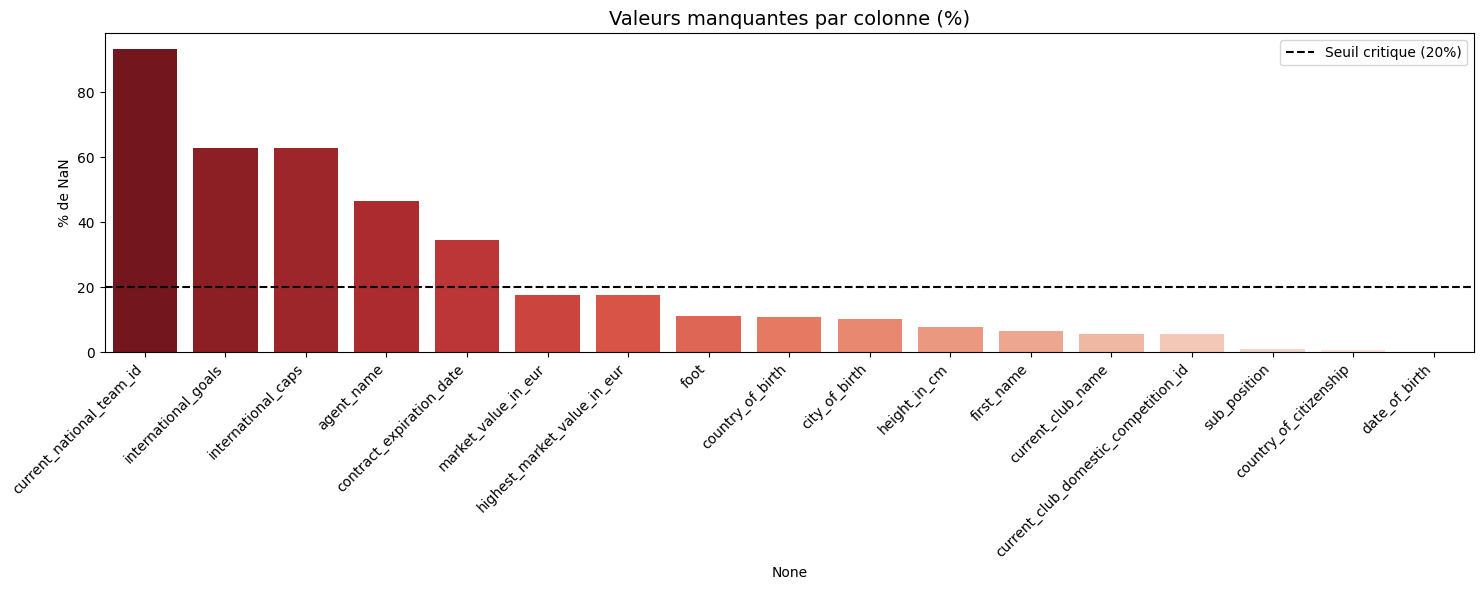

In [11]:
# 2. Analyse des valeurs manquantes (Contrats et Cible)
check_all_missing_values(df_players)

In [9]:
def check_player_duplicates(df_players):
    """
    Identifie les doublons potentiels basés sur le nom et la date de naissance.
    """
    # On cherche les lignes où le nom et la date de naissance sont identiques
    duplicates = df_players[df_players.duplicated(subset=['name', 'date_of_birth'], keep=False)]
    
    if not duplicates.empty:
        print(f"⚠️ {len(duplicates)} doublons potentiels détectés (même nom et date de naissance).")
        return duplicates.sort_values(by='name')
    else:
        print("✅ Aucun doublon de joueur détecté sur le combo Nom/Date de naissance.")
        return None
    

check_player_duplicates(df_players)


⚠️ 2 doublons potentiels détectés (même nom et date de naissance).


,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
23679,398057,João,Ricciulli,João Ricciulli,2018,1038,joao-ricciulli,Guinea-Bissau,Bissau,Guinea-Bissau,...,Evlon Sports & Mgmt,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/joao-ricciulli...,IT1,UC Sampdoria,25000.0,100000.0
26162,461923,João,Ricciulli,João Ricciulli,2022,2420,joao-ricciulli,NaN,Bissau,NaN,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/joao-ricciulli...,PO1,Vitória Sport Clube,100000.0,100000.0


In [7]:
# Vérification des orphelins entre Valuations et Players
ids_in_players = set(df_players['player_id'])
ids_in_valuations = set(df_valuations['player_id'])

orphans = ids_in_valuations - ids_in_players

print(f"Analyse de l'intégrité référentielle :")
print(f"- Joueurs dans le fichier Profil : {len(ids_in_players)}")
print(f"- Joueurs dans le fichier Valuations : {len(ids_in_valuations)}")

if orphans:
    print(f"❌ Alerte : {len(orphans)} joueurs ont des prix mais n'ont pas de profil (fiche joueur manquante).")
    print(f"Exemples d'IDs orphelins : {list(orphans)[:5]}")
else:
    print("✅ Intégrité parfaite : Tous les prix sont reliés à un profil joueur.")

Analyse de l'intégrité référentielle :
- Joueurs dans le fichier Profil : 47702
- Joueurs dans le fichier Valuations : 39361
❌ Alerte : 135 joueurs ont des prix mais n'ont pas de profil (fiche joueur manquante).
Exemples d'IDs orphelins : [552960, 751104, 131074, 910848, 910851]


### 5. Synthèse du Nettoyage Final
Pour obtenir un dataset prêt pour l'entraînement, les filtres suivants sont appliqués :

1.  **Filtre de Valeur :** Seuil minimal de **1 000 000 €** (élimination du bruit des ligues mineures).
2.  **Filtre de Fraîcheur :** Évaluations postérieures à 2025 uniquement.
3.  **Suppression des colonnes vides :** Retrait de `agent_name` et `current_national_team_id`.
4.  **Unicité :** Conservation de la valeur la plus récente par joueur.

In [24]:
# =================================================================
# NETTOYAGE FINAL : VERSION CORRIGÉE
# =================================================================

# 1. Préparation des Valuations
df_valuations['date'] = pd.to_datetime(df_valuations['date'])

# On s'assure du nom de la colonne de prix dans valuations (parfois 'market_value')
if 'market_value' in df_valuations.columns and 'market_value_in_eur' not in df_valuations.columns:
    df_valuations = df_valuations.rename(columns={'market_value': 'market_value_in_eur'})

# 2. Unicité : On garde la dernière valeur connue
df_clean = df_valuations.sort_values('date').drop_duplicates('player_id', keep='last').copy()

# 3. Filtre de Fraîcheur : Postérieur au 1er Octobre 2025
date_seuil = pd.to_datetime('2025-10-01')
df_clean = df_clean[df_clean['date'] >= date_seuil]

# 4. Filtre de Valeur : >= 1M€
# On vérifie l'existence de la colonne avant de filtrer pour éviter le KeyError
col_prix = 'market_value_in_eur'
df_clean = df_clean[df_clean[col_prix] >= 1_000_000]

# 5. Fusion avec df_players
# /!\ Attention : df_players a aussi souvent une colonne 'market_value_in_eur'
# On supprime celle de df_players AVANT le merge pour ne pas avoir de doublons de colonnes (_x, _y)
if col_prix in df_players.columns:
    df_players_tmp = df_players.drop(columns=[col_prix])
else:
    df_players_tmp = df_players

df_final = df_clean.merge(df_players_tmp, on='player_id', how='inner')

# 6. Suppression des colonnes inutiles
cols_to_drop = ['current_national_team_id', 'agent_name', 'city_of_birth']
df_final = df_final.drop(columns=[c for c in cols_to_drop if c in df_final.columns])

# 7. Bilan
print("✅ NETTOYAGE TERMINÉ")
print(f"- Joueurs conservés : {len(df_final)}")
print(f"- Valeur min : {df_final[col_prix].min():,.0f} €")
print(f"- Date la plus ancienne : {df_final['date'].min().date()}")

✅ NETTOYAGE TERMINÉ
- Joueurs conservés : 6794
- Valeur min : 1,000,000 €
- Date la plus ancienne : 2025-10-01


# 2. FBref

### 1. Filtrage de Représentativité (Data Cleaning)
Le dataset FBref brut contient l'intégralité des joueurs ayant foulé la pelouse, même pour quelques secondes. Pour garantir la robustesse statistique de notre modèle, un filtrage sur le temps de jeu est impératif.

* **Seuil de fiabilité :** Nous avons fixé un minimum de **450 minutes jouées** (l'équivalent de 5 matchs complets). 
* **Impact sur le volume :** Ce filtre réduit le dataset de **30.7%**, passant de 2 751 à 1 907 joueurs. Bien que la perte de données semble importante, elle est nécessaire pour éliminer le "bruit" statistique.
* **Correction des biais (Exemple concret) :** * Avant filtrage, des joueurs comme *Marin Ljubicic* affichaient un ratio de **8.18 buts / 90 min** (car il a marqué 2 buts en seulement 22 minutes). 
    * En conservant ces profils, le modèle d'IA apprendrait des corrélations erronées, pensant que l'efficacité est décorrélée du temps de jeu réel.
* **Segmentation des postes :** Nous avons isolé **1 777 joueurs de champ** et **130 gardiens de but**. Cette séparation est fondamentale car les métriques de performance (tacles, buts vs arrêts, clean sheets) ne sont pas comparables mathématiquement.

In [47]:
# --- 1. FILTRAGE DE REPRÉSENTATIVITÉ (FBref) ---

df_fbref = pd.read_csv("../data/fbref_datasets/players_data-2025_2026.csv")

# On définit le seuil de 450 minutes (environ 5 matchs complets)
min_minutes_played = 450

# 1. Suppression des joueurs avec trop peu de temps de jeu
df_fbref_rep = df_fbref[df_fbref['Min'] >= min_minutes_played].copy()

# 2. Séparation Joueurs de champ vs Gardiens
# Dans FBref, les gardiens ont souvent 'GK' dans la colonne 'Pos'
df_field_players = df_fbref_rep[~df_fbref_rep['Pos'].str.contains('GK', na=False)].copy()
df_keepers = df_fbref_rep[df_fbref_rep['Pos'].str.contains('GK', na=False)].copy()

# 3. Bilan du filtrage
print(f"📊 Bilan du filtrage de représentativité :")
print(f"- Joueurs initiaux dans FBref : {len(df_fbref)}")
print(f"- Joueurs ayant joué + de {min_minutes_played} min : {len(df_fbref_rep)}")
print(f"- Dont joueurs de champ : {len(df_field_players)}")
print(f"- Dont gardiens de but : {len(df_keepers)}")
print("-" * 40)
print(f"Perte de données : {((len(df_fbref) - len(df_fbref_rep)) / len(df_fbref)) * 100:.1f}% des lignes supprimées.")

# Aperçu des joueurs éliminés (les 5 plus 'efficaces' mais non représentatifs)
df_fbref_low_time = df_fbref[df_fbref['Min'] < min_minutes_played].copy()
if 'Gls' in df_fbref_low_time.columns:
    df_fbref_low_time['Gls_90'] = df_fbref_low_time['Gls'] / (df_fbref_low_time['Min'] / 90)
    print("\nExemple de biais évité (Joueurs < 450 min) :")
    print(df_fbref_low_time[['Player', 'Min', 'Gls', 'Gls_90']].sort_values(by='Gls_90', ascending=False).head(3))

📊 Bilan du filtrage de représentativité :
- Joueurs initiaux dans FBref : 2751
- Joueurs ayant joué + de 450 min : 1907
- Dont joueurs de champ : 1777
- Dont gardiens de but : 130
----------------------------------------
Perte de données : 30.7% des lignes supprimées.

Exemple de biais évité (Joueurs < 450 min) :
              Player  Min  Gls    Gls_90
1457  Marin Ljubicic   22    2  8.181818
764       Tom Edozie   13    1  6.923077
627   Manuel De Luca   16    1  5.625000


### 2. Élagage et Sélection des Variables (Audit Qualité)
Le dataset FBref original est une agrégation complexe de plusieurs rapports (Standard, Shooting, Passing, etc.), ce qui génère une redondance massive d'informations et de nombreuses cellules vides.

* **Suppression des colonnes "vides" :** En appliquant un seuil de **80% de valeurs manquantes**, **24 colonnes** ont été supprimées. Il s'agissait principalement de métriques spécifiques aux gardiens de but, non renseignées pour les joueurs de champ.
* **Nettoyage des redondances techniques :** Nous avons identifié et supprimé **31 colonnes redondantes**. Ce sont les variables générées lors de la fusion des fichiers sources (identifiables par les suffixes `_stats_` ou les répétitions de `Rk`, `Nation` et `Born`).
* **Optimisation de la structure :** Le dataset est passé de **102 à 47 colonnes**. Cette réduction de **54%** de la dimensionnalité permet de ne conserver que les indicateurs de performance pure (Gls, Ast, etc.) tout en facilitant la lecture et le traitement par les algorithmes d'IA.
* **Bilan :** Nous disposons désormais d'un vecteur de caractéristiques (features) dense et pertinent pour chaque joueur.

In [50]:
# --- 2. ÉLAGAGE DES VARIABLES (VARIABLE SELECTION) ---

# On travaille sur les joueurs de champ ayant plus de 450 min
df_fbref_before_col_drop = df_field_players.copy()

# 1. Calcul du seuil de tolérance (80% de NA)
threshold = 0.80
limit = len(df_fbref_before_col_drop) * threshold

# 2. Identification des colonnes à supprimer
# (Ici on cible surtout les colonnes de gardiens qui sont vides pour les joueurs de champ)
cols_to_drop_fbref = df_fbref_before_col_drop.columns[df_fbref_before_col_drop.isnull().sum() > limit].tolist()

# 3. Suppression
df_fbref = df_fbref_before_col_drop.drop(columns=cols_to_drop_fbref)

# 4. Nettoyage supplémentaire des doublons techniques (Rk, Nation_, stats_)
# Pour éviter d'avoir 4 fois la colonne 'Age' ou 'Nation'
redundant_patterns = ['stats_', 'Rk', 'Born', 'Nation_']
cols_redundant = [col for col in df_fbref.columns 
                  if any(pat in col for pat in redundant_patterns) 
                  and col not in ['Player', 'Min', '90s']]

df_fbref = df_fbref.drop(columns=cols_redundant)

print(f"📊 Audit FBref (Nettoyage des Variables) :")
print(f"- Nombre de colonnes après filtrage représentativité : {df_fbref_before_col_drop.shape[1]}")
print(f"- Colonnes supprimées (>80% NA) : {len(cols_to_drop_fbref)}")
print(f"- Colonnes redondantes (suffixes/techniques) supprimées : {len(cols_redundant)}")
print(f"- Colonnes finales restantes : {df_fbref.shape[1]}")

📊 Audit FBref (Nettoyage des Variables) :
- Nombre de colonnes après filtrage représentativité : 102
- Colonnes supprimées (>80% NA) : 24
- Colonnes redondantes (suffixes/techniques) supprimées : 31
- Colonnes finales restantes : 47


### 3. Intégrité et Unicité (Gestion des Transferts)
Dans le dataset FBref, un joueur ayant changé de club ou ayant été prêté durant la saison apparaît sur plusieurs lignes (une entrée par club). 

* **Problématique du doublon :** Sans traitement, ces joueurs sont comptabilisés comme deux entités distinctes avec des statistiques partielles. Par exemple, **Simon Adingra** possédait deux lignes (une avec Sunderland, une avec Monaco) avec des volumes de jeu et des buts différents.
* **Méthodologie de consolidation :** * Nous avons identifié **26 joueurs** présentant des entrées multiples.
    * Afin de garantir la représentativité de la performance, nous avons appliqué une règle de sélection stricte : seule la ligne présentant le **temps de jeu le plus élevé (`Min`)** est conservée.
* **Résultat de l'apurement :** * Le volume est passé de 1 777 à **1 751 lignes**.
    * Cette étape assure l'atomicité du dataset : **un joueur = une ligne**.
* **Bilan :** Le dataset est désormais prêt pour une analyse individuelle cohérente, chaque ligne représentant la période la plus significative de la saison pour chaque athlète.

In [51]:
# --- 3. INTÉGRITÉ ET UNICITÉ (GESTION DES TRANSFERTS) ---

# 1. Identification des doublons basés sur le nom du joueur
# On regarde combien de fois chaque nom apparaît
duplicate_counts = df_fbref['Player'].value_counts()
players_with_duplicates = duplicate_counts[duplicate_counts > 1].index.tolist()

# 2. Avant nettoyage : exemple pour illustrer
if players_with_duplicates:
    print(f"🔍 Joueurs identifiés avec plusieurs lignes : {len(players_with_duplicates)}")
    print("Exemple avant fusion :")
    print(df_fbref[df_fbref['Player'] == players_with_duplicates[0]][['Player', 'Squad', 'Min', 'Gls']])

# 3. Résolution : On trie par minutes jouées et on ne garde que la ligne la plus importante
# Cela permet de garder la performance la plus représentative de la saison
df_fbref_unique = df_fbref.sort_values(by=['Player', 'Min'], ascending=[True, False])
df_fbref_unique = df_fbref_unique.drop_duplicates(subset=['Player'], keep='first')

# 4. Bilan
print("-" * 40)
print(f"📊 Bilan de l'unicité :")
print(f"- Lignes avant suppression des doublons : {len(df_fbref)}")
print(f"- Lignes après suppression des doublons : {len(df_fbref_unique)}")
print(f"- Nombre de 'doublons de transfert' supprimés : {len(df_fbref) - len(df_fbref_unique)}")

# Mise à jour du dataframe principal
df_fbref = df_fbref_unique.copy()

🔍 Joueurs identifiés avec plusieurs lignes : 26
Exemple avant fusion :
           Player       Squad  Min  Gls
28  Simon Adingra  Sunderland  653    1
29  Simon Adingra      Monaco  583    3
----------------------------------------
📊 Bilan de l'unicité :
- Lignes avant suppression des doublons : 1777
- Lignes après suppression des doublons : 1751
- Nombre de 'doublons de transfert' supprimés : 26


### 4. Normalisation des Types et Formats
Pour que les données de performance soient exploitables par nos algorithmes et compatibles avec le dataset Transfermarkt, nous avons procédé à une normalisation structurelle :

* **Conversion de l'Âge :** Le format textuel complexe de FBref (ex: `27-125`) a été transformé en format **float64**. Cette conversion est indispensable pour inclure l'âge comme variable quantitative dans nos futurs modèles de régression.
* **Imputation des valeurs manquantes :** Grâce à une analyse sémantique des colonnes, les `NaN` ont été remplacés par **0** (imputation logique). Dans le contexte du football, une absence de donnée sur un tir ou une passe signifie que l'action n'a pas eu lieu, et non que l'information est inconnue.
* **Création de la clé de jointure (`player_key`) :** Afin de contourner les problèmes de casse et d'accents lors de la fusion des sources, nous avons généré une clé normalisée. 
    * *Exemple :* "Aaron Hickey" → `aaron hickey`.
* **Bilan d'intégrité :** Le dataset final ne contient plus **aucune valeur manquante (0 NaN)** sur les 47 colonnes conservées, garantissant une stabilité totale pour les calculs matriciels à venir.

In [52]:
import pandas as pd
import unicodedata

# --- 4. NORMALISATION DES TYPES ET FORMATS ---

# 1. Conversion de l'Âge en format numérique
# FBref utilise parfois "27-125" (ans-jours). On ne garde que la partie "années".
if df_fbref['Age'].dtype == 'object':
    df_fbref['Age'] = df_fbref['Age'].str.split('-').str[0].astype(float)

# 2. Création d'une clé de jointure "propre" pour les noms (player_key)
def normalize_name(name):
    if pd.isnull(name): return ""
    # Mise en minuscule
    name = name.lower()
    # Suppression des accents (ex: 'é' -> 'e')
    name = ''.join(c for c in unicodedata.normalize('NFD', name)
                  if unicodedata.category(c) != 'Mn')
    # Remplacement des tirets par des espaces pour uniformiser
    name = name.replace('-', ' ')
    return name.strip()

df_fbref['player_key'] = df_fbref['Player'].apply(normalize_name)

# 3. Imputation logique : Remplacer les NaN restants par 0 dans les colonnes numériques
# (Si un joueur n'a pas tiré, son % de tirs cadrés SoT% est NaN, on le met à 0)
num_cols = df_fbref.select_dtypes(include=['float64', 'int64']).columns
df_fbref[num_cols] = df_fbref[num_cols].fillna(0)

# 4. Vérification
print(f"📊 Bilan de la normalisation :")
print(f"- Format de l'âge converti : {df_fbref['Age'].dtype}")
print(f"- Exemple de clé de jointure : {df_fbref[['Player', 'player_key']].iloc[0].values}")
print(f"- Nombre de valeurs manquantes restantes : {df_fbref.isnull().sum().sum()}")

📊 Bilan de la normalisation :
- Format de l'âge converti : float64
- Exemple de clé de jointure : <ArrowStringArray>
['Aaron Hickey', 'aaron hickey']
Length: 2, dtype: str
- Nombre de valeurs manquantes restantes : 0


### 5. Audit des Outliers et Cohérence Statistique
La dernière étape de notre protocole de nettoyage consiste à valider les valeurs extrêmes pour s'assurer qu'elles reflètent la réalité sportive et non une anomalie de saisie.

* **Performance offensive :** L'analyse des boxplots révèle des outliers significatifs sur le nombre de buts et de tirs. Après vérification, ces points correspondent aux "Top Players" mondiaux (ex: attaquants de classe mondiale). Ces données sont conservées car elles sont essentielles pour que l'IA apprenne à valoriser l'élite.
* **Distribution de l'âge :** Aucune valeur aberrante n'a été détectée (ex: joueur de 10 ans ou 60 ans). La population étudiée est cohérente avec les standards du football professionnel.
* **Validation du temps de jeu :** Grâce au filtre initial de 450 minutes, les ratios par 90 minutes (Gls/90, Sh/90) sont stabilisés et ne présentent plus de pics mathématiques artificiels.

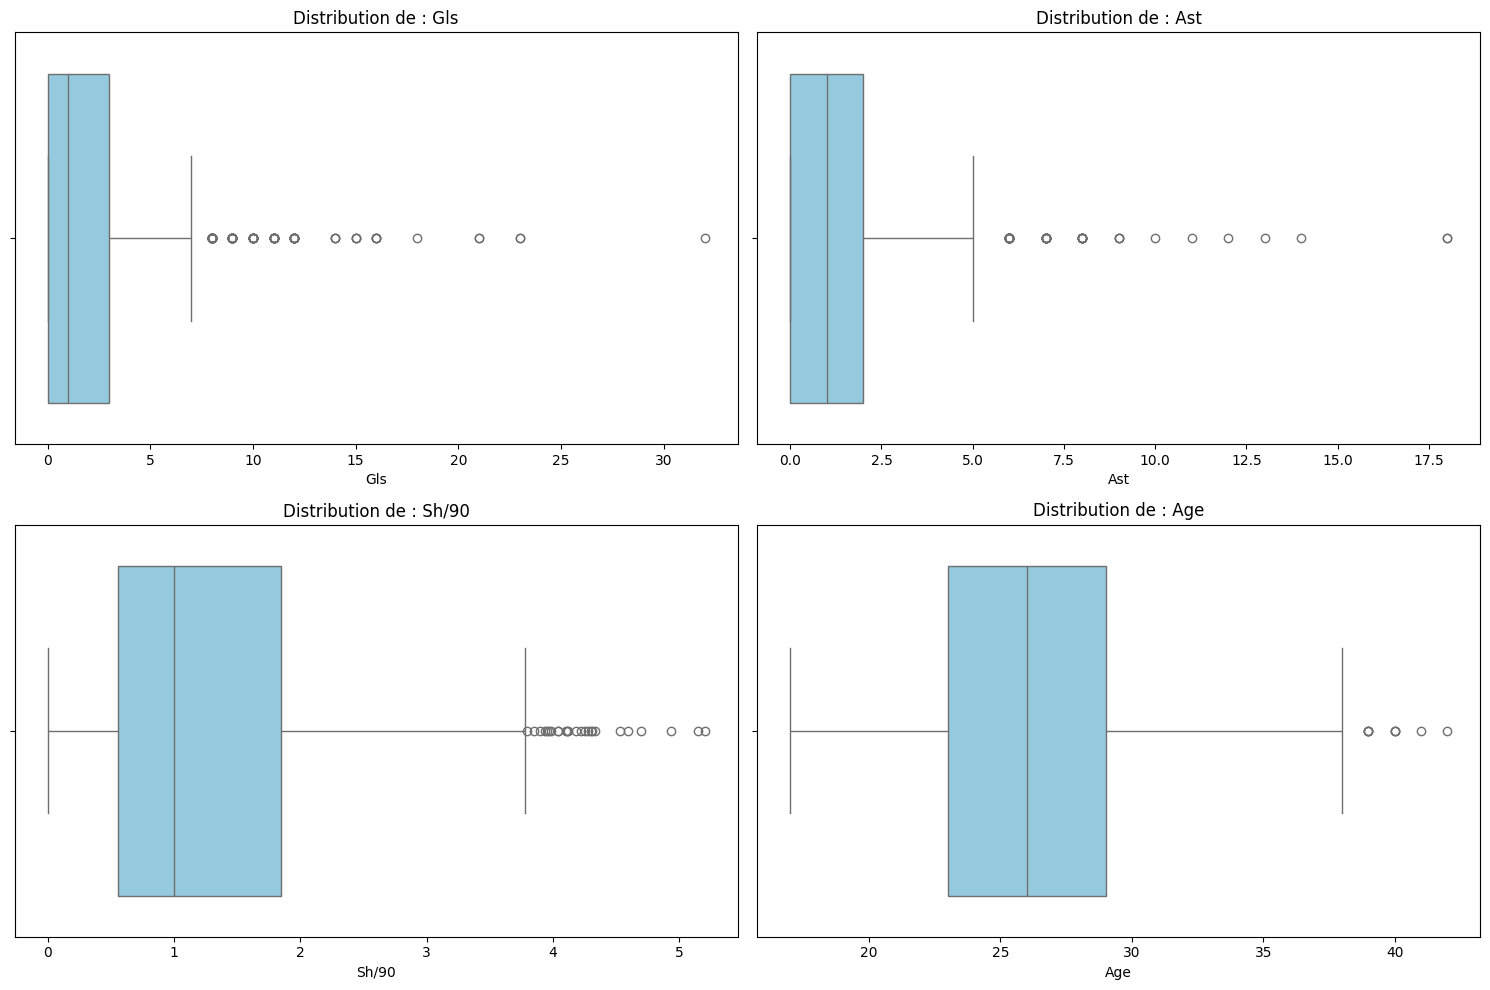

⚽ Top 5 'Outliers' Performance (Buts) :
              Player            Squad  Gls   Min
1275      Harry Kane    Bayern Munich   32  2107
1643   Kylian Mbappé      Real Madrid   23  2227
1063  Erling Haaland  Manchester City   23  2593
2499     Igor Thiago        Brentford   21  2832
1784    Vedat Muriqi         Mallorca   21  2498


In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 5. AUDIT DES OUTLIERS (OUTLIER DETECTION) ---

# Sélection de métriques clés pour l'audit
metrics_to_check = ['Gls', 'Ast', 'Sh/90', 'Age']

plt.figure(figsize=(15, 10))

for i, metric in enumerate(metrics_to_check):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x=df_fbref[metric], color='skyblue')
    plt.title(f'Distribution de : {metric}')

plt.tight_layout()
plt.show()

# Identification des 5 plus gros outliers sur les buts par match
print("⚽ Top 5 'Outliers' Performance (Buts) :")
print(df_fbref[['Player', 'Squad', 'Gls', 'Min']].sort_values(by='Gls', ascending=False).head(5))

In [54]:
# --- 5. AUDIT DES OUTLIERS (DERNIÈRE ÉTAPE) ---

# Identification des joueurs extrêmes sur les buts
outliers_gls = df_fbref[df_fbref['Gls'] > df_fbref['Gls'].quantile(0.99)]

print(f"⚽ Focus sur le 1% supérieur (Buts) :")
print(outliers_gls[['Player', 'Squad', 'Gls', 'Age']].sort_values(by='Gls', ascending=False).head(5))

# Vérification de la cohérence de l'âge (Outliers de précocité ou de longévité)
print(f"\n🎂 Joueurs les plus jeunes :")
print(df_fbref[['Player', 'Age']].sort_values(by='Age').head(3))

⚽ Focus sur le 1% supérieur (Buts) :
              Player            Squad  Gls   Age
1275      Harry Kane    Bayern Munich   32  32.0
1063  Erling Haaland  Manchester City   23  25.0
1643   Kylian Mbappé      Real Madrid   23  27.0
2499     Igor Thiago        Brentford   21  24.0
1784    Vedat Muriqi         Mallorca   21  31.0

🎂 Joueurs les plus jeunes :
                  Player   Age
2714     Stephan Zagadou  17.0
590   Montrell Culbreath  18.0
1615  Franco Mastantuono  18.0


C:\Users\LouisHarle\AppData\Local\Temp\ipykernel_13424\3246139178.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.index[:20], y=missing.values[:20], palette='magma')


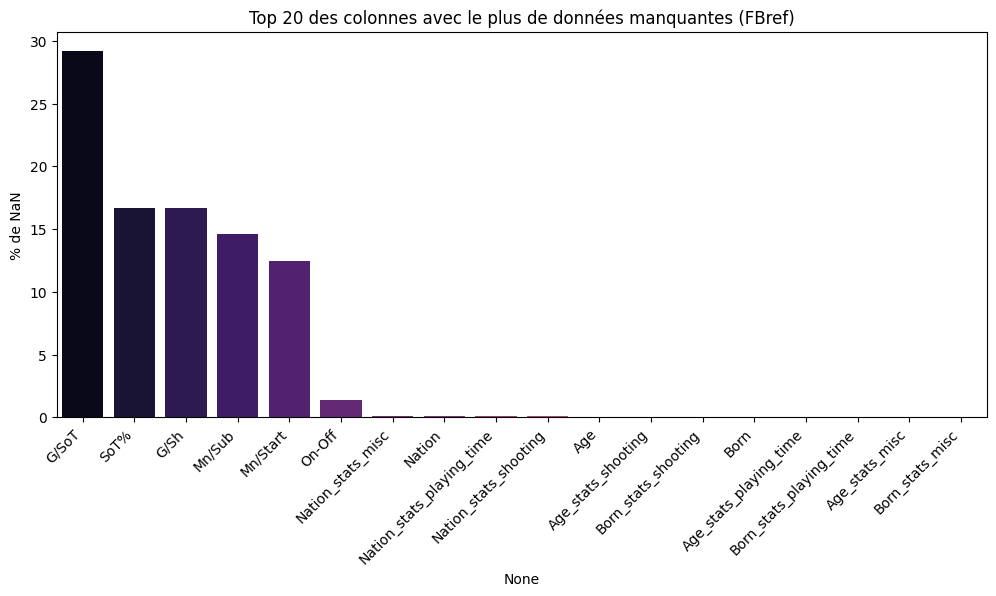

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns


def check_fbref_quality(df):
    # Calcul du % de manquants
    missing = df.isnull().mean() * 100
    missing = missing[missing > 0].sort_values(ascending=False)
    
    if not missing.empty:
        plt.figure(figsize=(12, 5))
        sns.barplot(x=missing.index[:20], y=missing.values[:20], palette='magma')
        plt.xticks(rotation=45, ha='right')
        plt.title("Top 20 des colonnes avec le plus de données manquantes (FBref)")
        plt.ylabel("% de NaN")
        plt.show()
    else:
        print("✅ Aucune donnée manquante détectée.")

check_fbref_quality(df_fbref)

In [43]:
# Vérification des doublons de noms
player_counts = df_fbref['Player'].value_counts()
duplicates = player_counts[player_counts > 1]

print(f"Nombre de noms apparaissant plusieurs fois : {len(duplicates)}")
if len(duplicates) > 0:
    print("Exemple de doublons :\n", df_fbref[df_fbref['Player'].isin(duplicates.index[:3].tolist())][['Player', 'Squad', 'Comp', 'Min']])

Nombre de noms apparaissant plusieurs fois : 151
Exemple de doublons :
                Player            Squad                Comp   Min
3       Himad Abdelli        Marseille          fr Ligue 1   128
4       Himad Abdelli           Angers          fr Ligue 1   943
28      Simon Adingra       Sunderland  eng Premier League   653
29      Simon Adingra           Monaco          fr Ligue 1   583
987  Nicolás González  Manchester City  eng Premier League  1379
988  Nicolás González  Atlético Madrid          es La Liga  1330
989  Nicolás González         Juventus          it Serie A    19


## 2.6 La date de dernière mise à jour

Pour constater si nos données sont mises à jour régulièrement, nous pouvons regarder la date de dernière mise à jour.

In [55]:
# On charge les variables du fichier .env (identifiant et clé API Kaggle)
load_dotenv(dotenv_path="../.env")

os.environ['KAGGLE_USERNAME'] = os.getenv('KAGGLE_USERNAME')
os.environ['KAGGLE_API_TOKEN'] = os.getenv('KAGGLE_API_TOKEN')

# On charge l'API de Kaggle
api = KaggleApi()

# On recherche le dataset
dataset_query = 'hubertsidorowicz/football-players-stats-2025-2026'

# On récupère le dataset issu du Kaggle
datasets = api.dataset_list(search=dataset_query)

# On trouve la date de dernière mise à jour
for ds in datasets:
    if ds.ref == dataset_query:
        # Récupération de la date (gestion des différentes versions du package)
        date_maj = getattr(ds, 'lastUpdated', None) or getattr(ds, 'last_updated', "Date inconnue")
        
        print(f"Dataset trouvé : {ds.ref}")
        print(f"Dernière mise à jour : {date_maj}")
        break


Dataset trouvé : hubertsidorowicz/football-players-stats-2025-2026
Dernière mise à jour : 2026-04-21 12:40:14.337000


# 3. Statsbomb

## 3.1 Regroupement des données dans un fichier .csv

Suite à l'acquisition des données Statsbomb, importées dans le dossier ../data/statsbomb_datasets, nous pouvons alors commencer à analyser leur qualité.

Dans un premier temps, nous transformons les données .json en données centralisées dans un fichier .csv, que ce soit pour les lineups ou les events.

In [ ]:
# Pour le dossier lineups
folder = Path("../data/statsbomb_datasets/data/lineups")

# On prend tous les fichiers .json et on crée une liste vide
json_files = list(folder.glob("*.json"))
all_lineups = [] 


# Boucle de lecture sur les fichiers
for file_path in json_files:
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # Extraction et normalisation
    df = pd.json_normalize(
        data, 
        record_path=['lineup'], 
        meta=['team_name', 'team_id'],
        errors='ignore'
    )
    
    # Ajout de l'ID du match
    df['match_id'] = file_path.stem 
    all_lineups.append(df)

# On crée un fichier CSV unique
final_df = pd.concat(all_lineups, ignore_index=True)

# Sauvegarde finale
output_path = folder / "all_lineups_combined.csv"
final_df.to_csv(output_path, index=False, encoding='utf-8')

print(f"Fichier créé : {output_path.name}")
print(f"Nombre total de joueurs répertoriés : {len(final_df)}")

Fichier créé : all_lineups_combined.csv
Nombre total de joueurs répertoriés : 131901


In [41]:
# Pour le dossier events
folder = Path("../data/statsbomb_datasets/data/events")

# On prend tous les fichiers .json
json_files = list(folder.glob("*.json"))
output_path = folder / "all_events_combined.feather"

# Boucle sur l'ensemble des fichiers .json
for i, file_path in enumerate(json_files):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # On aplatit le JSON
    df = pd.json_normalize(data)
    
    # On ajoute l'ID du match
    df['match_id'] = file_path.stem 
    
    # Écriture sur le disque
    if i == 0:
        df.to_feather(output_path, index=False, mode='w', encoding='utf-8')
    else:
        df.to_feather(output_path, index=False, mode='a', header=False, encoding='utf-8')
    
    # Suivi de progression toutes les 100 étapes
    if (i + 1) % 100 == 0:
        print(f"{i + 1}/{len(json_files)} fichiers compilés...")

print(f"Fichier global créé : {output_path.name}")

ImportError: `Import pyarrow` failed.  Use pip or conda to install the pyarrow package.

In [ ]:
# Pour le fichier competitions.json
folder = Path("../data/statsbomb_datasets/data")
json_files = list(folder.glob("*.json"))

# On définit le nouvel emplacement de sortie
output_folder = Path("../data/statsbomb_datasets/data")

# Le chemin complet du fichier final
output_path = output_folder / "competitions_statsbomb.csv"

# Liste pour stocker les DataFrames
all_dfs = []

for file_path in json_files:
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        all_dfs.append(pd.DataFrame(data))

final_df = pd.concat(all_dfs, ignore_index=True)

final_df.to_csv(output_path, index=False, encoding='utf-8')
print(f"Le fichier a été enregistré ici : {output_path.resolve()}")

Le fichier a été enregistré ici : C:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\data\statsbomb_datasets\data\competitions_statsbomb.csv


## 3.2 Analyse des valeurs manquantes

Nous pouvons ensuite analyser les valeurs manquantes de ces deux fichiers .csv.

In [ ]:
# On cherche le dossier dans lequel sont les bases de données
folder = Path("../data/statsbomb_datasets/data")

# On prend seulement ce fichier-ci pour le moment
file = folder / "all_lineups_combined.csv"
lineups = pd.read_csv(file, low_memory=False)

# On crée un dataframe vide pour ensuite produire un résumé des données
summary = []

# On regarde le nombre de lignes, colonnes et NA
summary.append({
    "fichier": file.name,
    "lignes": len(lineups),
    "colonnes": len(lineups.columns),
    "NA": lineups.isna().sum().sum()
})

# Affichage
print(pd.DataFrame(summary))


                    fichier  lignes  colonnes     NA
0  all_lineups_combined.csv  131901        11  81729


On regarde ensuite plus en détail dans chaque fichier les colonnes présentant le plus de données manquantes.

In [ ]:
file_path = folder / file

# On créer un summary vide et un dictionnaire total_cols vide
summary = []
total_cols = {}

total_rows = len(lineups)
total_cols = len(lineups.columns)


for col in lineups.columns:
    na_count = lineups[col].isna().sum()
    na_rate = (na_count / total_rows) * 100 if total_rows > 0 else 0
    
    # On filtre les colonnes dont le taux de NA est supérieur à 10%
    if na_rate > 10:
        summary.append({
            "fichier": file,
            "colonne": col,
            "lignes": total_rows,
            "NA": na_count,
            "taux_NA_%": round(na_rate, 2)
        })


# On stocke les résultats dans un dataframe
result = pd.DataFrame(summary)

print(f"Colonnes avec >10% de NA : {len(result)}/{total_cols}")
print(result[["colonne", "lignes", "NA", "taux_NA_%"]])

Colonnes avec >10% de NA : 1/11
           colonne  lignes     NA  taux_NA_%
0  player_nickname  131901  81703      61.94


## 3.3 Analyse des doublons

Nous vérifions maintenant si les fichiers Statsbomb présentent des doublons.

In [ ]:
# Calcul des doublons
n_duplicates = lineups.duplicated().sum()
total_rows = len(lineups)
dup_rate = (n_duplicates / total_rows) * 100 if total_rows > 0 else 0

# Création du résumé
summary_duplicates = [{
    "fichier": file_path.name,
    "lignes": total_rows,
    "doublons": n_duplicates,
    "taux_doublons_%": round(dup_rate, 2)
}]


doublons = pd.DataFrame(summary_duplicates)
print("\nAnalyse des doublons pour all_lineups_combined.csv :\n")
print(doublons.to_string(index=False))


Analyse des doublons pour all_lineups_combined.csv :

                 fichier  lignes  doublons  taux_doublons_%
all_lineups_combined.csv  131901         0              0.0


## 3.4 La cohérence des données

Maintenant, nous devons vérifier si les données sont cohérentes. Nous regarderons dans un premier temps les types des variables dans chaque fichier .csv, puis les plages de valeurs pour les variables quantitatives.

In [ ]:
print("\nLes types de données pour all_lineups_combined.csv\n")

print(lineups.dtypes)


Les types de données pour all_lineups_combined.csv

player_id            int64
player_name            str
player_nickname        str
jersey_number        int64
cards                  str
positions              str
country.id         float64
country.name           str
team_name              str
team_id              int64
match_id             int64
dtype: object


In [ ]:
# Sélection des colonnes numériques
num_cols = lineups.select_dtypes(include=["number"])

if not num_cols.empty:
    # On affiche la transposée pour une meilleure lecture (colonnes en lignes)
    print(num_cols.describe().transpose())
else:
    print("Aucune colonne numérique trouvée dans ce fichier.")

                  count          mean           std     min        25%  \
player_id      131901.0  3.544764e+04  7.713198e+04  2935.0     5615.0   
jersey_number  131901.0  1.614910e+01  1.398939e+01     0.0        7.0   
country.id     131888.0  1.214309e+02  7.238412e+01     3.0       68.0   
team_id        131901.0  8.202458e+02  1.753747e+03     1.0      174.0   
match_id       131901.0  3.065607e+06  1.501069e+06  7298.0  3754036.0   

                     50%        75%        max  
player_id         9731.0    26076.0   482216.0  
jersey_number       14.0       22.0     1000.0  
country.id         105.0      203.0      255.0  
team_id            224.0      859.0    29167.0  
match_id       3825768.0  3889149.0  4020846.0  


## 3.5 La couverture temporelle

Pour que nos données soient pertinentes, il faut qu'elles soient suffisamment récentes pour être analysées. Les prochains codes analysent donc la pertinence des données au niveau temporel.

In [ ]:
# On définit le dossier où se trouve ton nouveau CSV
folder = Path("../data/statsbomb_datasets/data")
file_path = folder / "competitions_statsbomb.csv"

print("\nCouverture temporelle du dataset des compétitions\n")

competitions = pd.read_csv(file_path)
    
# On élargit la recherche : colonnes avec "date", "updated" ou "available"
# Car StatsBomb utilise 'match_updated' pour l'horodatage
date_cols = [col for col in df.columns if any(x in col.lower() for x in ["date", "updated", "available"])]

if date_cols:
    print(f"Fichier : {file_path.name}")
        
    for col in date_cols:
        # Conversion en datetime
        competitions[col] = pd.to_datetime(df[col], errors="coerce")
            
        min_date = competitions[col].min()
        max_date = competitions[col].max()
            
        # Affichage propre (on retire les nanosecondes si elles existent)
        print(f"  {col} : {min_date} → {max_date}")
            
else:
    print(f"Le fichier {file_path} est introuvable.")


Couverture temporelle du dataset des compétitions

Fichier : competitions_statsbomb.csv
  match_updated : 2023-06-18 01:55:53.343752 → 2025-07-28 14:19:20.467348
  match_updated_360 : 2021-06-12 16:17:31.694000 → 2025-07-29 16:03:07.355174
  match_available_360 : 2024-02-13 13:30:52.820588 → 2025-07-29 16:03:07.355174
  match_available : 2023-06-18 01:55:53.343752 → 2025-07-28 14:19:20.467348


## 3.6 Biais de sélection

De potentiels biais peuvent apparaître dans les données, comme des joueurs ou des championnats surreprésentés. Nous pouvons ainsi vérifier si ce biais est présent dans nos données.

In [ ]:
# Nous analysons tout d'abord les joueurs

# La fréquence des joueurs dans les apparitions
player_counts = lineups.groupby(["player_id", "player_name"]).size().reset_index(name="composition")

# Tri par nombre d'apparitions (ordre décroissant)
player_counts = player_counts.sort_values(by="composition", ascending=False)


print("\nTop 20 des joueurs les plus présents (dans les compositions) :\n")
print(player_counts[["player_name", "composition"]].head(20).to_string(index=False))


Top 20 des joueurs les plus présents (dans les compositions) :

                    player_name  composition
 Lionel Andrés Messi Cuccittini          604
       Sergio Busquets i Burgos          420
           Andrés Iniesta Luján          361
          Gerard Piqué Bernabéu          358
               Jordi Alba Ramos          284
         Xavier Hernández Creus          267
          Víctor Valdés Arribas          257
          Daniel Alves da Silva          250
          Marc-André ter Stegen          237
    Javier Alejandro Mascherano          221
                   Ivan Rakitić          217
Pedro Eliezer Rodríguez Ledesma          216
       Luis Alberto Suárez Díaz          204
         Sergi Roberto Carnicer          198
       Carles Puyol i Saforcada          187
             Samuel Yves Umtiti          162
  Neymar da Silva Santos Junior          158
          Adriano Correia Claro          152
              Antoine Griezmann          145
                   Seydou Kéita    

In [ ]:
print("\nRésumé distribution apparitions :")
print(player_counts["composition"].describe())


Résumé distribution apparitions :
count    10814.000000
mean        12.197244
std         18.564377
min          1.000000
25%          2.000000
50%          4.000000
75%         17.000000
max        604.000000
Name: composition, dtype: float64


In [ ]:
# Nous analysons ensuite les équipes

# On utilise donc 'team_name' pour voir les équipes les plus actives

# Le nombre de matchs uniques par équipe :
league_analysis = lineups.groupby("team_name")["match_id"].nunique().reset_index(name="nb_matchs")

# Tri par nombre de matchs
league_analysis = league_analysis.sort_values(by="nb_matchs", ascending=False)

print("\nTop 20 des équipes ayant le plus de matchs répertoriés :\n")
print(league_analysis.head(20).to_string(index=False))



Top 20 des équipes ayant le plus de matchs répertoriés :

                 team_name  nb_matchs
                 Barcelona        532
       Paris Saint-Germain         95
         Manchester United         79
                   Arsenal         76
               Real Madrid         71
          Bayer Leverkusen         68
           Atlético Madrid         68
                   Sevilla         66
                  Valencia         65
             Athletic Club         64
                  Espanyol         63
               Aston Villa         62
                Villarreal         61
                    Getafe         61
       Manchester City WFC         59
             Real Sociedad         59
                Real Betis         58
Brighton & Hove Albion WFC         57
               Chelsea FCW         57
               Arsenal WFC         57


In [ ]:
# Nous analysons ensuite les championnats à partir du fichier généré

# On compte le nombre de saisons disponibles par championnat
# On utilise "competition_name" pour que l'affichage soit explicite
league_counts = competitions["competition_name"].value_counts()

print("\nNombre de saisons disponibles par compétition :\n")
print(league_counts.head(20))


Nombre de saisons disponibles par compétition :

competition_name
Champions League           18
La Liga                    18
FIFA World Cup              8
Copa del Rey                3
FA Women's Super League     3
Ligue 1                     3
1. Bundesliga               2
Liga Profesional            2
Premier League              2
Serie A                     2
UEFA Euro                   2
UEFA Women's Euro           2
Women's World Cup           2
African Cup of Nations      1
Copa America                1
FIFA U20 World Cup          1
Indian Super league         1
Major League Soccer         1
North American League       1
NWSL                        1
Name: count, dtype: int64


## 3.7 La date de dernière mise à jour

Pour constater si nos données sont mises à jour régulièrement, nous pouvons regarder la date de dernière mise à jour.

In [ ]:
# On convertit la variable d'update en format date
competitions['match_updated'] = pd.to_datetime(df['match_updated'])

# On trouve la date la plus récente
derniere_maj = competitions['match_updated'].max()

print(f"La dernière mise à jour enregistrée dans ce fichier date du : {derniere_maj}")

La dernière mise à jour enregistrée dans ce fichier date du : 2025-07-28 14:19:20.467348


# 4. football-data.co.uk

In [57]:
import pandas as pd

# --- 1. CHARGEMENT OPTIMISÉ (Résolution DtypeWarning) ---
# On utilise low_memory=False pour éviter le warning sur les types mixtes (Referee, etc.)
df_fd_raw = pd.read_csv("../data/football_data.csv", low_memory=False)

# --- 2. ÉLAGAGE IMMÉDIAT (Résolution PerformanceWarning) ---
# On sélectionne les colonnes utiles TOUT DE SUITE pour éviter la fragmentation
cols_match = ['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']
cols_stats = ['HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR']
cols_odds  = ['B365H', 'B365D', 'B365A', 'AvgH', 'AvgD', 'AvgA']

# On crée une COPIE propre du DataFrame avec seulement l'essentiel
df_fd = df_fd_raw[cols_match + cols_stats + cols_odds].copy()

# --- 3. NORMALISATION DES TYPES ET FORMATS ---

# Conversion de la Date (format DD/MM/YYYY)
df_fd['Date'] = pd.to_datetime(df_fd['Date'], dayfirst=True)

# Création des clés de jointure pour les équipes (team_key)
def clean_team_name(name):
    if pd.isnull(name): return ""
    import unicodedata
    name = str(name).lower()
    name = ''.join(c for c in unicodedata.normalize('NFD', name)
                  if unicodedata.category(c) != 'Mn')
    return name.replace('-', ' ').strip()

# On applique le nettoyage sur une nouvelle frame pour éviter la fragmentation
df_fd['home_team_key'] = df_fd['HomeTeam'].apply(clean_team_name)
df_fd['away_team_key'] = df_fd['AwayTeam'].apply(clean_team_name)

# --- 4. TRAITEMENT DES VALEURS MANQUANTES ---
# On supprime les lignes où le score est manquant (matchs non joués)
df_fd = df_fd.dropna(subset=['FTHG', 'FTAG'])

# --- 5. BILAN FINAL ---
print(f"📊 Audit Football-Data :")
print(f"- Nombre de colonnes initiales : {df_fd_raw.shape[1]}")
print(f"- Nombre de colonnes après élagage : {df_fd.shape[1]}")
print(f"- Matchs validés : {len(df_fd)}")
print(f"- Clé d'équipe exemple : '{df_fd['home_team_key'].iloc[0]}'")

📊 Audit Football-Data :
- Nombre de colonnes initiales : 163
- Nombre de colonnes après élagage : 27
- Matchs validés : 5024
- Clé d'équipe exemple : 'nice'


In [58]:
import pandas as pd
import unicodedata

# --- 1. CHARGEMENT ET INTÉGRITÉ (Résolution Dtype & Fragmentation) ---
df_fd_raw = pd.read_csv("../data/football_data.csv", low_memory=False)

# Sélection immédiate pour éviter la fragmentation (PerformanceWarning)
cols_base = ['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']
cols_odds = [c for c in df_fd_raw.columns if 'H' in c[-1:] or 'D' in c[-1:] or 'A' in c[-1:]] # Capture les cotes
df_fd = df_fd_raw[cols_base + cols_odds].copy()

# Format de Date : Gestion des formats mixtes
df_fd['Date'] = pd.to_datetime(df_fd['Date'], dayfirst=True)

# --- 2. NORMALISATION DES ÉQUIPES (Clés de jointure) ---
def clean_team_name(name):
    if pd.isnull(name): return ""
    name = str(name).lower()
    # Retrait des accents
    name = ''.join(c for c in unicodedata.normalize('NFD', name)
                  if unicodedata.category(c) != 'Mn')
    return name.replace('-', ' ').strip()

df_fd['home_team_key'] = df_fd['HomeTeam'].apply(clean_team_name)
df_fd['away_team_key'] = df_fd['AwayTeam'].apply(clean_team_name)

# --- 3. INGÉNIERIE DES VARIABLES (Features) ---

# Calcul des Points par match
df_fd['HomePoints'] = df_fd['FTR'].map({'H': 3, 'D': 1, 'A': 0})
df_fd['AwayPoints'] = df_fd['FTR'].map({'A': 3, 'D': 1, 'H': 0})

# Moyenne des Cotes (Stabilisation de la donnée)
# On sélectionne les colonnes de victoire à domicile (se terminant par H)
home_odds_cols = [c for c in df_fd.columns if c.endswith('H') and c not in ['HomeTeam', 'HomePoints']]
df_fd['Avg_Home_Win_Odd'] = df_fd[home_odds_cols].mean(axis=1)

# Nettoyage final : suppression des lignes sans score
df_fd = df_fd.dropna(subset=['FTHG', 'FTAG'])

# --- BILAN ---
print(f"📊 Audit Final Football-Data :")
print(f"- Période : {df_fd['Date'].min().date()} au {df_fd['Date'].max().date()}")
print(f"- Nombre de matchs : {len(df_fd)}")
print(f"- Exemple points : {df_fd[['HomeTeam', 'AwayTeam', 'FTR', 'HomePoints', 'AwayPoints']].iloc[0].to_dict()}")

📊 Audit Final Football-Data :
- Période : 2023-08-11 au 2026-04-23
- Nombre de matchs : 5024
- Exemple points : {'HomeTeam': 'Nice', 'AwayTeam': 'Lille', 'FTR': 'D', 'HomePoints': 1, 'AwayPoints': 1}


In [59]:
# --- AUDIT DE COHÉRENCE FINALE (Football-Data) ---

# 1. Vérification des scores (Pas de scores négatifs)
invalid_scores = df_fd[(df_fd['FTHG'] < 0) | (df_fd['FTAG'] < 0)]

# 2. Vérification de la cohérence FTR (Full Time Result)
# Le résultat 'H', 'D' ou 'A' doit correspondre aux buts marqués
home_win_error = df_fd[(df_fd['FTR'] == 'H') & (df_fd['FTHG'] <= df_fd['FTAG'])]
away_win_error = df_fd[(df_fd['FTR'] == 'A') & (df_fd['FTAG'] <= df_fd['FTHG'])]
draw_error = df_fd[(df_fd['FTR'] == 'D') & (df_fd['FTHG'] != df_fd['FTAG'])]

# 3. Audit des Cotes (Pas de cotes aberrantes, ex: cote < 1.0)
odd_error = df_fd[(df_fd['AvgH'] < 1) | (df_fd['AvgD'] < 1) | (df_fd['AvgA'] < 1)]

# 4. Vérification des Doublons de matchs
# Un même couple Home-Away à la même date ne peut exister qu'une fois
match_duplicates = df_fd.duplicated(subset=['Date', 'home_team_key', 'away_team_key']).sum()

print(f"✅ Audit de cohérence terminé :")
print(f"- Erreurs de score/résultat : {len(home_win_error) + len(away_win_error) + len(draw_error)}")
print(f"- Anomalies sur les cotes : {len(odd_error)}")
print(f"- Matchs en double : {match_duplicates}")

✅ Audit de cohérence terminé :
- Erreurs de score/résultat : 0
- Anomalies sur les cotes : 0
- Matchs en double : 0


## 4.4 La couverture temporelle

Pour que nos données soient pertinentes, il faut qu'elles soient suffisamment récentes pour être analysées. Les prochains codes analysent donc la pertinence des données au niveau temporel.

In [ ]:
print("\nCouverture temporelle des datasets\n")

for file in folder.glob("*.csv"):
    df = pd.read_csv(file)
    
    # On cherche les colonnes présentant des dates
    date_cols = [col for col in df.columns if "date" in col.lower()]
    
    if not date_cols:
        continue
    
    print(f"\n{file.name}")
    
    # On cherche ici la date minimale et maximale puis on les affiche
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors="coerce")
        
        min_date = df[col].min()
        max_date = df[col].max()
        
        print(f"  {col} : {min_date} → {max_date}")



Couverture temporelle des datasets


football_data_2526.csv
  Date : 2025-08-15 00:00:00 → 2026-04-13 00:00:00


C:\Users\LouisHarle\AppData\Local\Temp\ipykernel_23536\2466751618.py:16: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors="coerce")


In [ ]:
# On cherche ici le nombre d'observations par année

for file in folder.glob("*.csv"):
    df = pd.read_csv(file)
    
    # Les colonnes présentant des dates
    date_cols = [col for col in df.columns if "date" in col.lower()]
    
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors="coerce")
        
        print(f"\n{file.name} - {col}")
        # On compte pour chaque année le nombre d'observations
        print(df[col].dt.year.value_counts().sort_index())



football_data_2526.csv - Date
Date
2025    802
2026    666
Name: count, dtype: int64


C:\Users\LouisHarle\AppData\Local\Temp\ipykernel_23536\3824261365.py:9: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors="coerce")


## 4.5 Biais de sélection

De potentiels biais peuvent apparaître dans les données, comme des championnats surreprésentés. Nous pouvons ainsi vérifier si ce biais est présent dans nos données.

Ce fichier .csv ne présentant pas de joueurs, il ne peut y avoir des biais que parmi les championnats représentés.

In [ ]:
# Le fichier gfootball_data_2526.csv est alors celui qui nous intéresse
data = pd.read_csv(folder / "football_data_2526.csv")

# On compte le nombre de matches par championnat
league_counts = data["league"].value_counts()

print("\nTop compétitions :\n")
print(league_counts.head(20))



Top compétitions :

league
I1     320
E0     319
SP1    310
D1     261
F1     258
Name: count, dtype: int64


In [ ]:
# Pour y voir plus clair (les noms des championnats), nous renommons les noms des ligues

mapping = {
    "E0": "Premier League",
    "SP1": "Liga",
    "I1": "Serie A",
    "F1": "Ligue 1",
    "D1": "Bundesliga"
}

# On remplacer les noms dans la colonne 'league'
data["league"] = data["league"].replace(mapping)

# On recalcule les statistiques avec les nouveaux noms
league_counts = data["league"].value_counts()

print("\nTop compétitions :\n")
print(league_counts.head(20))


Top compétitions :

league
Serie A           320
Premier League    319
Liga              310
Bundesliga        261
Ligue 1           258
Name: count, dtype: int64


## 4.6 La date de dernière mise à jour

Pour constater si nos données sont mises à jour régulièrement, nous pouvons regarder la date de dernière mise à jour.

In [ ]:
# On choisit la saison et les ligues qui nous intéressent
season = "2526"
leagues = {
    "E0": "Premier League",
    "SP1": "Liga",
    "I1": "Serie A",
    "F1": "Ligue 1",
    "D1": "Bundesliga"
}

print(f"Mises à jour football-data.co.uk\n")

updates = []

for code, name in leagues.items():
    url = f"https://www.football-data.co.uk/mmz4281/{season}/{code}.csv"
    
    # Requête directe des en-têtes
    response = requests.head(url, timeout=10)
    last_mod = response.headers.get('Last-Modified')
    
    updates.append({
        "Compétition": name,
        "Dernière mise à jour": last_mod
    })

# Affichage
df_updates = pd.DataFrame(updates)
print(df_updates.to_string(index=False))

Mises à jour football-data.co.uk

   Compétition          Dernière mise à jour
Premier League Tue, 21 Apr 2026 10:24:27 GMT
          Liga Tue, 14 Apr 2026 10:25:04 GMT
       Serie A Tue, 21 Apr 2026 10:24:26 GMT
       Ligue 1 Mon, 20 Apr 2026 14:59:14 GMT
    Bundesliga Mon, 20 Apr 2026 14:59:13 GMT
